# DynaSD Quickstart

End-to-end seizure detection on a bundled synthetic example.

This notebook walks through the four steps that make up every DynaSD pipeline:

1. **Load data** — get a seizure recording.
2. **Fit** — calibrate a detector on the baseline portion.
3. **Forward** — score every window of the full recording.
4. **Annotate** — call `get_onset_and_spread` to extract per-channel onset times.

We use the closed-form `HFER` detector here for speed; every detector class in
`DynaSD.__all__` (e.g. `ABSSLP`, `IMPRINT`, `NDD`, `GIN`, `LiNDDA`) follows the
same `fit` → `forward` → `get_onset_and_spread` interface.


## 1. Load the bundled example

`DynaSD.load_example_seizure()` returns a synthetic 60 s recording (8 channels,
fs=256 Hz) with a polyspike seizure planted at t=30 s on the first 4 channels.
The remaining 4 channels stay baseline throughout.

In [ ]:
# If DynaSD isn't installed, fall back to importing from the repo root.
import sys, pathlib
_repo = pathlib.Path.cwd().parent
if (_repo / 'DynaSD').is_dir() and str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dynasd import HFER, load_example_seizure

example = load_example_seizure()
X = example.signal              # pd.DataFrame, shape (n_samples, n_channels)
fs = example.fs                 # 256 Hz
sz_start = example.seizure_start_sec   # 30.0
sz_end = example.seizure_end_sec       # 60.0
focal = example.focal_channels         # ['Ch01', 'Ch02', 'Ch03', 'Ch04']

print(f"signal: {X.shape}  fs={fs}  duration={len(X)/fs:.1f}s")
print(f"planted seizure: {sz_start}-{sz_end}s on {focal}")

Quick look at the raw signal — focal channels in red, baseline in black.

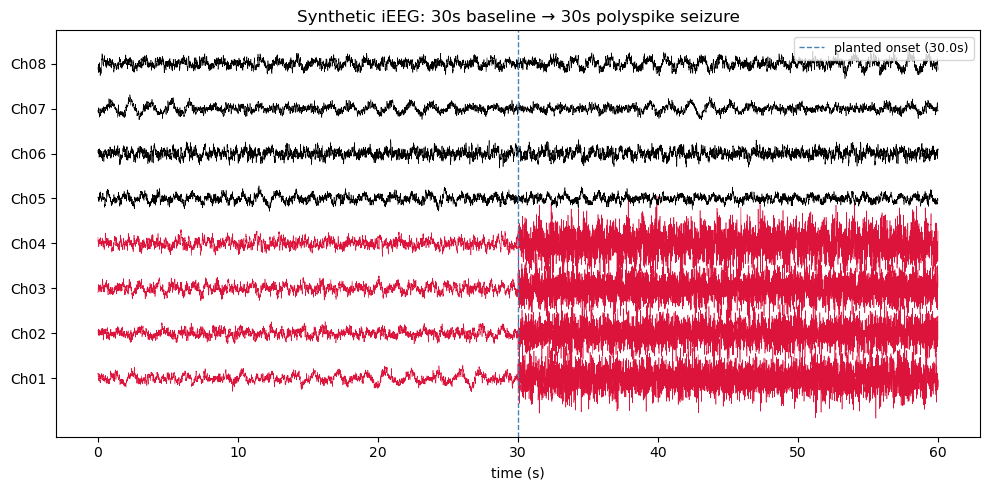

In [2]:
t = np.arange(len(X)) / fs
fig, ax = plt.subplots(figsize=(10, 5))
spacing = X.std().median() * 8
for i, ch in enumerate(X.columns):
    color = "crimson" if ch in focal else "black"
    ax.plot(t, X[ch].values - X[ch].mean() + i * spacing, color=color, lw=0.4)
ax.axvline(sz_start, color="steelblue", ls="--", lw=1, label=f"planted onset ({sz_start}s)")
ax.set_yticks([i * spacing for i in range(len(X.columns))])
ax.set_yticklabels(X.columns)
ax.set_xlabel("time (s)")
ax.set_title("Synthetic iEEG: 30s baseline → 30s polyspike seizure")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 2. Fit the detector on the baseline

Detectors learn per-channel reference statistics from a stretch of pre-ictal
data. Pass only the baseline portion to `fit`.

In [3]:
baseline = X.iloc[: int(sz_start * fs)]   # first 30 seconds

model = HFER(fs=fs, w_size=1.0, w_stride=0.5)
model.fit(baseline)
print(f"model fitted: {model.is_fitted}")

model fitted: True


## 3. Forward-pass the full recording

`model.forward(X)` returns a `pd.DataFrame` of per-window detector scores. The
row index is the window-start time in seconds (named ``t_sec``); columns match
the input channel names.

In [4]:
sz_prob = model(X)
print(f"sz_prob: {sz_prob.shape}  index name='{sz_prob.index.name}'")
sz_prob.head()

sz_prob: (119, 8)  index name='t_sec'


,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08
t_sec,,,,,,,,
0.0,0.681297,0.309717,0.496864,0.303883,0.744889,0.524364,1.196222,0.257725
0.5,0.437108,0.865664,1.022851,1.484190,1.524428,0.833351,0.326716,0.247494
1.0,0.720892,0.648854,4.532057,0.359944,1.493482,0.327490,0.228026,0.747713
1.5,3.139069,0.667332,0.338741,0.319491,0.657080,0.374541,0.532331,1.291026
2.0,0.604084,1.068440,0.630426,0.490594,0.889788,1.603790,0.387690,0.444119


## 4. Annotate onset and spread

`get_onset_and_spread` smooths the per-window scores, thresholds them, and
applies a sustained-activity criterion to extract per-channel seizure onset
times.

**Key parameters** (all in seconds):
- `threshold` — score above which a window counts as seizing.
- `filter_w` — smoothing window length (uniform filter on the score).
- `rwin_size` — lookahead span for the spread criterion.
- `rwin_req` — required active duration within `rwin_size` to flag onset.

The defaults (`filter_w=10s, rwin_size=5s, rwin_req=4s`) work well; pick
`threshold` based on the baseline distribution. For HFER on this fixture,
`threshold=8.0` separates baseline from seizure cleanly.

In [5]:
onsets, sz_spread = model.get_onset_and_spread(
    sz_prob,
    threshold=8.0,
    filter_w=10.0,
    rwin_size=5.0,
    rwin_req=4.0,
    ret_smooth_mat=True,
)

# ``onsets`` is a single-row DataFrame: per-channel onset time in seconds
# (NaN for channels that never reach sustained activity).
onsets.T.rename(columns={0: "detected_onset_sec"})

,detected_onset_sec
Ch01,27.5
Ch03,27.5
Ch02,28.5
Ch04,31.0
Ch05,NaN
Ch06,NaN
Ch07,NaN
Ch08,NaN


## 5. Visualize the result

Compare detected onsets to the planted onset.

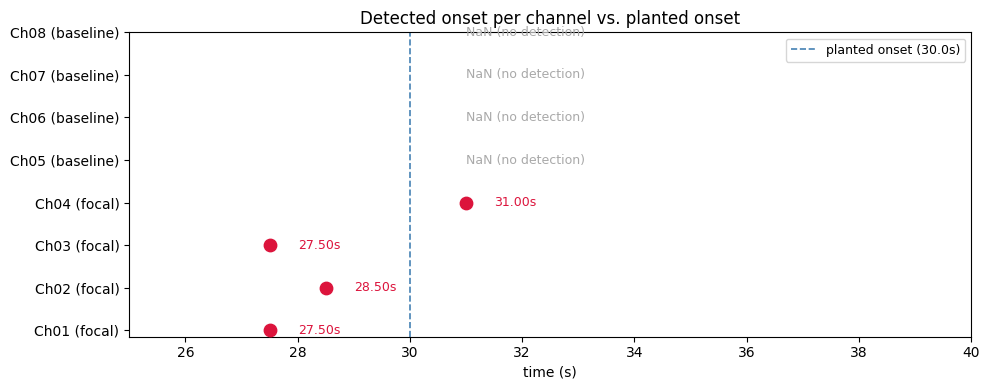

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axvline(sz_start, color="steelblue", ls="--", lw=1.2,
           label=f"planted onset ({sz_start}s)")
for i, ch in enumerate(X.columns):
    val = onsets[ch].iloc[0]
    is_focal = ch in focal
    color = "crimson" if is_focal else "darkgray"
    if pd.isna(val):
        ax.text(sz_start + 1, i, "NaN (no detection)", color=color,
                fontsize=9, va="center")
    else:
        ax.scatter([val], [i], color=color, s=80, zorder=5)
        ax.text(val + 0.5, i, f"{val:.2f}s", fontsize=9, va="center", color=color)
ax.set_yticks(range(len(X.columns)))
ax.set_yticklabels([f"{c} {'(focal)' if c in focal else '(baseline)'}" for c in X.columns])
ax.set_xlabel("time (s)")
ax.set_title("Detected onset per channel vs. planted onset")
ax.set_xlim(sz_start - 5, sz_start + 10)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()